### 🐼 Pandas Series — From NumPy Arrays to Labeled Data

This notebook covers pandas' `Series` — a labeled, 1-D companion to the NumPy arrays from the earlier notebooks. Same numeric engine underneath, plus a built-in index.

**What's covered, in order:**
1. 🐼 What is Pandas
2. 📦 Pandas Series
3. 📥 Importing Pandas
4. 📋 Series from Lists
5. 🗂️ Series from Dict
6. 📐 Series Attributes
7. 📄 Series using read_csv
8. 🛠️ Series Methods
9. ➗ Series Maths Methods
10. 🎯 Series Indexing
11. ✏️ Editing Series
12. 🧬 Copy and Views
13. 🐍 Series with Python Functionalities
14. ✅ Boolean Indexing on Series
15. 📉 Plotting Graphs on Series
16. 🔧 Some Important Series Methods
17. ✅ Key Takeaways

## 1. 🐼 What is Pandas

Pandas is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool,
built on top of the Python programming language.

https://pandas.pydata.org/about/index.html

## 2. 📦 Pandas Series

A Pandas Series is like a column in a table. It is a 1-D array holding data of any type.

## 3. 📥 Importing Pandas

In [1]:
import numpy as np
import pandas as pd

## 4. 📋 Series from Lists

In [2]:
# string
country = ['India','Pakistan','USA','Nepal','Srilanka']

pd.Series(country)

0       India
1    Pakistan
2         USA
3       Nepal
4    Srilanka
dtype: str

In [3]:
# integers
runs = [13,24,56,78,100]

runs_ser = pd.Series(runs)

In [4]:
# custom index
marks = [67,57,89,100]
subjects = ['maths','english','science','hindi']

pd.Series(marks,index=subjects)

maths       67
english     57
science     89
hindi      100
dtype: int64

In [5]:
# setting a name
marks = pd.Series(marks,index=subjects,name='Nitish ke marks')
marks

maths       67
english     57
science     89
hindi      100
Name: Nitish ke marks, dtype: int64

**Note:** without a custom `index`, pandas numbers rows `0, 1, 2, ...` automatically — set `index=` for meaningful labels, and `name=` to label the whole Series (useful later when it becomes a DataFrame column).

In [6]:
# dtype can be set explicitly too, just like with NumPy arrays
pd.Series([1, 2, 3], dtype='float64')

0    1.0
1    2.0
2    3.0
dtype: float64

## 5. 🗂️ Series from Dict

In [7]:
marks = {
    'maths':67,
    'english':57,
    'science':89,
    'hindi':100
}

marks_series = pd.Series(marks,name='nitish ke marks')
marks_series

maths       67
english     57
science     89
hindi      100
Name: nitish ke marks, dtype: int64

**Note:** dict keys automatically become the index and dict values become the data — equivalent to passing `index=` by hand, like in the previous section.

In [8]:
# pass index= to reorder or pick only some of the dict's keys
pd.Series(marks, index=['hindi', 'maths'])

hindi    100
maths     67
dtype: int64

## 6. 📐 Series Attributes

In [9]:
# size
marks_series.size

4

In [10]:
# dtype
marks_series.dtype

dtype('int64')

In [11]:
# name
marks_series.name

'nitish ke marks'

In [12]:
# is_unique
marks_series.is_unique

True

In [13]:
pd.Series([1,1,2,3,4,5]).is_unique

False

In [14]:
# index
marks_series.index

Index(['maths', 'english', 'science', 'hindi'], dtype='str')

In [15]:
# values
marks_series.values

array([ 67,  57,  89, 100])

In [16]:
runs_ser.index

RangeIndex(start=0, stop=5, step=1)

In [17]:
type(runs_ser.index)

pandas.RangeIndex

In [18]:
print(type(marks_series.values))   # numpy.ndarray -- proof a Series is a NumPy array with an index attached

<class 'numpy.ndarray'>


## 7. 📄 Series using read_csv

**Colab note:** `/content/...` is Google Colab's upload folder — running locally? Point the path at wherever you saved `subs.csv`, `kohli_ipl.csv`, and `bollywood.csv` instead.

**Note:** `squeeze=True` used to turn a single-column DataFrame straight into a Series, but it was **removed in pandas 2.0+**. The cells below use the modern replacement, `.squeeze("columns")`, which does the same job.

In [19]:
type(pd.read_csv('content/subs.csv').squeeze("columns"))

pandas.Series

In [20]:
type(pd.read_csv('content/subs.csv').squeeze("columns"))

pandas.Series

In [21]:
# with one col
subs = pd.read_csv('content/subs.csv').squeeze("columns")

subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [22]:
# with 2 cols
vk = pd.read_csv('content/kohli_ipl.csv',index_col='match_no').squeeze("columns")
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [23]:
movies = pd.read_csv('content/bollywood.csv',index_col='movie').squeeze("columns")
movies

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: str

## 8. 🛠️ Series Methods

In [24]:
# head and tail
subs.head()

0    48
1    57
2    40
3    43
4    44
Name: Subscribers gained, dtype: int64

In [25]:
vk.head(3)

match_no
1     1
2    23
3    13
Name: runs, dtype: int64

In [26]:
vk.tail(10)

match_no
206     0
207     0
208     9
209    58
210    30
211     0
212    20
213    73
214    25
215     7
Name: runs, dtype: int64

In [27]:
# sample
movies.sample(5)

movie
Newton (film)                  Rajkummar Rao
Muskaan                     Aftab Shivdasani
Dil Maange More                Shahid Kapoor
Insaaf: The Justice               Dino Morea
Chandni Chowk to China    Mithun Chakraborty
Name: lead, dtype: str

In [28]:
movies

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: str

In [29]:
# value_counts -> movies
movies.value_counts()

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
                    ..
Tanishaa Mukerji     1
Tanuja               1
Ankit                1
Rakhee Gulzar        1
Edwin Fernandes      1
Name: count, Length: 566, dtype: int64

**Note:** `value_counts()` counts how often each **value** shows up (not each index label), sorted from most to least common by default.

In [30]:
# sort_values -> inplace
vk.sort_values(ascending=True)

match_no
87       0
211      0
207      0
206      0
91       0
      ... 
164    100
120    100
123    108
126    109
128    113
Name: runs, Length: 215, dtype: int64

In [31]:
# sort_values -> inplace
vk.sort_values(ascending=False)

match_no
128    113
126    109
123    108
164    100
120    100
      ... 
93       0
211      0
130      0
8        0
135      0
Name: runs, Length: 215, dtype: int64

In [32]:
# sort values -> inplace method chaining
vk.sort_values(ascending=False).head(2).values[0]

np.int64(113)

In [33]:
vk.sort_values(ascending=False)

match_no
128    113
126    109
123    108
164    100
120    100
      ... 
93       0
211      0
130      0
8        0
135      0
Name: runs, Length: 215, dtype: int64

In [34]:
# sort_index -> inplace -> movies inplace will use to make the permanent changes in the array
movies.sort_index(ascending=False,inplace=True)
movies

movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
                                   ...        
2 States (2014 film)              Arjun Kapoor
1971 (2007 film)                Manoj Bajpayee
1920: The Evil Returns             Vicky Ahuja
1920: London                     Sharman Joshi
1920 (film)                   Rajniesh Duggall
Name: lead, Length: 1500, dtype: str

In [35]:
# sort_index -> inplace -> movies
movies.sort_index(ascending=True,inplace=True)
movies

movie
1920 (film)                   Rajniesh Duggall
1920: London                     Sharman Joshi
1920: The Evil Returns             Vicky Ahuja
1971 (2007 film)                Manoj Bajpayee
2 States (2014 film)              Arjun Kapoor
                                   ...        
Zindagi 50-50                      Veena Malik
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi Tere Naam           Mithun Chakraborty
Zokkomon                       Darsheel Safary
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Name: lead, Length: 1500, dtype: str

**Gotcha:** most methods (like a plain `sort_values()`) return a **new** Series and leave the original untouched. Passing `inplace=True` — like `vk.sort_values(inplace=True)` and `movies.sort_index(..., inplace=True)` above — permanently overwrites the original instead. Use it carefully.

## 9. ➗ Series Maths Methods

In [36]:
# count
vk.count().item()

215

In [37]:
movies.count().item()

1500

In [38]:
# sum -> product
subs.sum().item()

49510

In [39]:
# mean -> median -> mode -> std -> var
subs.mean()

np.float64(135.64383561643837)

In [40]:
print(vk.median())

24.0


In [41]:
print(movies.mode())

0    Akshay Kumar
Name: lead, dtype: str


In [42]:
print(subs.std()) ## standard deviation

62.6750230372527


In [43]:
print(vk.var()) ## variance

688.0024777222343


**Note:** `.mode()` can return **more than one value** (several tied "most common" numbers), which is why it prints differently from the single-number results above it.

In [44]:
# min/max
print(subs.max())
print(vk.max())
print(movies.max())

396
113
Zulfi Sayed


In [45]:
# describe
subs.describe()

count    365.000000
mean     135.643836
std       62.675023
min       33.000000
25%       88.000000
50%      123.000000
75%      177.000000
max      396.000000
Name: Subscribers gained, dtype: float64

In [46]:
# describe() gets count/mean/std/min/max/quartiles all at once, without calling each separately
vk.describe()

count    215.000000
mean      30.855814
std       26.229801
min        0.000000
25%        9.000000
50%       24.000000
75%       48.000000
max      113.000000
Name: runs, dtype: float64

## 10. 🎯 Series Indexing

**Note:** a Series supports two different indexing styles — **label-based** (matching an actual index value) and **position-based** (matching a 0-based slot, like a Python list). Modern pandas is strict about the difference: use `.loc[label]` for labels and `.iloc[position]` for positions to avoid the ambiguity below.

In [47]:
# integer indexing
x = pd.Series([12,13,14,35,46,57,58,79,9])
x

0    12
1    13
2    14
3    35
4    46
5    57
6    58
7    79
8     9
dtype: int64

In [48]:
# negative indexing is not working
# x[-1]

In [49]:
movies

movie
1920 (film)                   Rajniesh Duggall
1920: London                     Sharman Joshi
1920: The Evil Returns             Vicky Ahuja
1971 (2007 film)                Manoj Bajpayee
2 States (2014 film)              Arjun Kapoor
                                   ...        
Zindagi 50-50                      Veena Malik
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi Tere Naam           Mithun Chakraborty
Zokkomon                       Darsheel Safary
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Name: lead, Length: 1500, dtype: str

In [50]:
# Gets the first movie name
print(movies.index[0])  

# Gets the first actor name
print(movies.iloc[0])  

1920 (film)
Rajniesh Duggall


In [51]:
movies[-1:]

movie
Zor Lagaa Ke...Haiya!    Meghan Jadhav
Name: lead, dtype: str

**Gotcha — this breaks on modern pandas!** Older pandas silently fell back to *positional* lookup when a negative number wasn't a real label. That fallback is **gone** — `x[-1]`, `vk[-1]`, and `marks_series[-1]` above now raise `KeyError: -1`, because plain `[]` treats an integer as a **label**, not a position. Always use `.iloc[]` for "give me the Nth item":

In [52]:
print(x.iloc[-1])              # last item, by position -- always works
print(vk.iloc[-1])
print(marks_series.iloc[-1])

9
7
100


In [53]:
# slicing
vk[5:16]

match_no
6      9
7     34
8      0
9     21
10     3
11    10
12    38
13     3
14    11
15    50
16     2
Name: runs, dtype: int64

In [54]:
# negative slicing
vk[-5:]

match_no
211     0
212    20
213    73
214    25
215     7
Name: runs, dtype: int64

In [55]:
movies[::2]

movie
1920 (film)                 Rajniesh Duggall
1920: The Evil Returns           Vicky Ahuja
2 States (2014 film)            Arjun Kapoor
3 A.M. (2014 film)             Salil Acharya
3 Idiots                          Aamir Khan
                                  ...       
Zero (2018 film)              Shah Rukh Khan
Zila Ghaziabad                  Vivek Oberoi
Zindaggi Rocks                  Sushmita Sen
Zindagi Na Milegi Dobara      Hrithik Roshan
Zokkomon                     Darsheel Safary
Name: lead, Length: 750, dtype: str

**Note:** slicing (`start:stop:step`) is the one case where plain `[]` stays purely **positional**, even on a label-indexed Series — that's why `vk[5:16]`, `vk[-5:]`, and `movies[::2]` above all worked fine.

In [56]:
# fancy indexing
vk[[1,3,4,5]]

match_no
1     1
3    13
4    12
5     1
Name: runs, dtype: int64

In [57]:
# indexing with labels -> fancy indexing
movies['2 States (2014 film)']

'Arjun Kapoor'

In [58]:
movies['Fraud Saiyaan']

'Arshad Warsi'

In [59]:
# the safe, unambiguous way to write the slicing examples above, regardless of what the labels are
vk.iloc[5:16]   # .iloc -- always positional, no surprises

match_no
6      9
7     34
8      0
9     21
10     3
11    10
12    38
13     3
14    11
15    50
16     2
Name: runs, dtype: int64

## 11. ✏️ Editing Series

In [60]:
# using indexing
marks_series[1] = 100
marks_series

maths       67
english     57
science     89
hindi      100
1          100
Name: nitish ke marks, dtype: int64

**Gotcha — silently wrong, not even an error!** `marks_series` is indexed by subject *names*, so the integer `1` isn't treated as "position 1" — pandas treats it as a **brand-new label**. The line above didn't update `'english'` at all; it silently **appended a new row** labeled `1`:

In [61]:
print(marks_series)   # 'english' is still 57 -- and there's a new row labeled 1 with value 100

maths       67
english     57
science     89
hindi      100
1          100
Name: nitish ke marks, dtype: int64


**The correct way to edit by position:**

In [62]:
marks_series = pd.Series({'maths':67,'english':57,'science':89,'hindi':100})   # start fresh
marks_series.iloc[1] = 100    # position 1 = 'english'
marks_series

maths       67
english    100
science     89
hindi      100
dtype: int64

In [63]:
# what if an index does not exist
marks_series['evs'] = 89

In [64]:
marks_series

maths       67
english    100
science     89
hindi      100
evs         89
dtype: int64

In [65]:
# slicing
runs_ser[2:4] = [100,100]
runs_ser

0     13
1     24
2    100
3    100
4    100
dtype: int64

In [66]:
# fancy indexing
runs_ser[[0,3,4]] = [0,0,0]
runs_ser

0      0
1     24
2    100
3      0
4      0
dtype: int64

In [67]:
movies

movie
1920 (film)                   Rajniesh Duggall
1920: London                     Sharman Joshi
1920: The Evil Returns             Vicky Ahuja
1971 (2007 film)                Manoj Bajpayee
2 States (2014 film)              Arjun Kapoor
                                   ...        
Zindagi 50-50                      Veena Malik
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi Tere Naam           Mithun Chakraborty
Zokkomon                       Darsheel Safary
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Name: lead, Length: 1500, dtype: str

In [68]:
# using index label
movies['2 States (2014 film)'] = 'Alia Bhatt'
movies

movie
1920 (film)                   Rajniesh Duggall
1920: London                     Sharman Joshi
1920: The Evil Returns             Vicky Ahuja
1971 (2007 film)                Manoj Bajpayee
2 States (2014 film)                Alia Bhatt
                                   ...        
Zindagi 50-50                      Veena Malik
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi Tere Naam           Mithun Chakraborty
Zokkomon                       Darsheel Safary
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Name: lead, Length: 1500, dtype: str

In [69]:
# adding a brand-new label works the same way whether the Series came from a list or a dict
runs_ser['bonus_match'] = 50
runs_ser

0                0
1               24
2              100
3                0
4                0
bonus_match     50
dtype: int64

## 12. 🧬 Copy and Views

Just like NumPy arrays, a Series can hand back either a **view** (shares memory with the original) or a **copy** (fully independent) — the full worked example is in section 16 below. **Update for modern pandas:** since pandas 2.0 (mandatory from pandas 3.0 on), **Copy-on-Write (CoW)** is always active, so editing a slice like `series.head()` no longer silently mutates the original — pandas automatically makes a real copy the moment you write to it. Calling `.copy()` explicitly is still good practice (and required on older pandas), but the classic "silent mutation" footgun is fixed at the engine level.

In [70]:
demo = pd.Series([1, 2, 3, 4, 5])
view_like = demo.head(3)
view_like.iloc[0] = 999
print(demo)   # unaffected on modern pandas, thanks to Copy-on-Write

0    1
1    2
2    3
3    4
4    5
dtype: int64


## 13. 🐍 Series with Python Functionalities

In [90]:
# len/type/dir/sorted/max/min
print(len(subs))
print(type(subs))
print(sorted(subs))
print(min(subs))
print(max(subs))
print(dir(subs))

365
<class 'pandas.Series'>
[33, 33, 35, 37, 39, 40, 40, 40, 40, 42, 42, 43, 44, 44, 44, 45, 46, 46, 48, 49, 49, 49, 49, 50, 50, 50, 51, 54, 56, 56, 56, 56, 57, 61, 62, 64, 65, 65, 66, 66, 66, 66, 67, 68, 70, 70, 70, 71, 71, 72, 72, 72, 72, 72, 73, 74, 74, 75, 76, 76, 76, 76, 77, 77, 78, 78, 78, 79, 79, 80, 80, 80, 81, 81, 82, 82, 83, 83, 83, 84, 84, 84, 85, 86, 86, 86, 87, 87, 87, 87, 88, 88, 88, 88, 88, 89, 89, 89, 90, 90, 90, 90, 91, 92, 92, 92, 93, 93, 93, 93, 95, 95, 96, 96, 96, 96, 97, 97, 98, 98, 99, 99, 100, 100, 100, 101, 101, 101, 102, 102, 103, 103, 104, 104, 104, 105, 105, 105, 105, 105, 105, 105, 105, 105, 108, 108, 108, 108, 108, 108, 109, 109, 110, 110, 110, 111, 111, 112, 113, 113, 113, 114, 114, 114, 114, 115, 115, 115, 115, 117, 117, 117, 118, 118, 119, 119, 119, 119, 120, 122, 123, 123, 123, 123, 123, 124, 125, 126, 127, 128, 128, 129, 130, 131, 131, 132, 132, 134, 134, 134, 135, 135, 136, 136, 136, 137, 138, 138, 138, 139, 140, 144, 145, 146, 146, 146, 146, 147, 149

In [72]:
# type conversion
list(marks_series)

[67, 100, 89, 100, 89]

In [73]:
dict(marks_series)

{'maths': np.int64(67),
 'english': np.int64(100),
 'science': np.int64(89),
 'hindi': np.int64(100),
 'evs': np.int64(89)}

**Note:** converting to `list()`/`dict()` drops all pandas-specific behavior (no more `.iloc`, no more automatic index alignment) — you're back to plain Python types.

In [74]:
# membership operator

'2 States (2014 film)' in movies

True

In [75]:
'Alia Bhatt' in movies.values

True

**Gotcha:** `in` checks the **index** by default (`'x' in series`), not the values — matching how `in` works on a Python dict (checks keys). To search the values instead, check membership against `.values` explicitly, like the line above does.

In [76]:
movies

movie
1920 (film)                   Rajniesh Duggall
1920: London                     Sharman Joshi
1920: The Evil Returns             Vicky Ahuja
1971 (2007 film)                Manoj Bajpayee
2 States (2014 film)                Alia Bhatt
                                   ...        
Zindagi 50-50                      Veena Malik
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi Tere Naam           Mithun Chakraborty
Zokkomon                       Darsheel Safary
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Name: lead, Length: 1500, dtype: str

In [77]:
# looping
for i in movies.index:
  print(i)

1920 (film)
1920: London
1920: The Evil Returns
1971 (2007 film)
2 States (2014 film)
22 Yards
3 A.M. (2014 film)
3 Deewarein
3 Idiots
3 Storeys
31st October (film)
36 China Town
3G (film)
404 (film)
5 Weddings
68 Pages
7 Hours to Go
7 Khoon Maaf
7½ Phere
88 Antop Hill
99 (2009 film)
99.9 FM (film)
?: A Question Mark
A Decent Arrangement
A Flat (film)
A Flying Jatt
A Gentleman
ABCD 2
Aa Dekhen Zara
Aa Gaya Hero
Aabra Ka Daabra
Aag (2007 film)
Aagey Se Right
Aaj Ka Andha Kanoon
Aaja Nachle
Aakhari Decision
Aakrosh (2010 film)
Aalaap (film)
Aan: Men at Work
Aanch
Aankhen (2002 film)
Aap Kaa Surroor
Aap Ki Khatir (2006 film)
Aapko Pehle Bhi Kahin Dekha Hai
Aarakshan
Aashayein
Aashiq Banaya Aapne
Aashiqui 2
Aashiqui.in
Aasma: The Sky Is the Limit
Aazaan
Ab Tak Chhappan 2
Ab Tumhare Hawale Watan Saathiyo
Accident on Hill Road
Acid Factory
Action Jackson (2014 film)
Action Replayy
Adharm (2006 film)
Ae Dil Hai Mushkil
Aetbaar
Agent Vinod (2012 film)
Aggar (film)
Agneepath (2012 film)
Agnipan

In [78]:
# Arithmetic Operators(Broadcasting)
100 + marks_series

maths      167
english    200
science    189
hindi      200
evs        189
dtype: int64

In [79]:
# Relational Operators

vk >= 50

match_no
1      False
2      False
3      False
4      False
5      False
       ...  
211    False
212    False
213     True
214    False
215    False
Name: runs, Length: 215, dtype: bool

In [80]:
# comparisons return a boolean Series -- same idea as NumPy boolean masks from the earlier notebooks
(vk >= 50).sum()   # True counts as 1, so summing counts how many matches there were

np.int64(50)

## 14. ✅ Boolean Indexing on Series

In [81]:
# Find no of 50's and 100's scored by kohli
vk[vk >= 50].size

50

In [82]:
# find number of ducks
vk[vk == 0].size

9

In [83]:
# Count number of day when I had more than 200 subs a day
subs[subs > 200].size

59

In [84]:
# find actors who have done more than 20 movies
num_movies = movies.value_counts()
num_movies[num_movies > 20]

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
Shah Rukh Khan      22
Emraan Hashmi       21
Name: count, dtype: int64

In [85]:
# combine conditions with & / | / ~ -- same rule as NumPy boolean masks
vk[(vk >= 50) & (vk < 100)].size   # how many innings scored between 50 and 99

45

## 15. 📉 Plotting Graphs on Series

<Axes: >

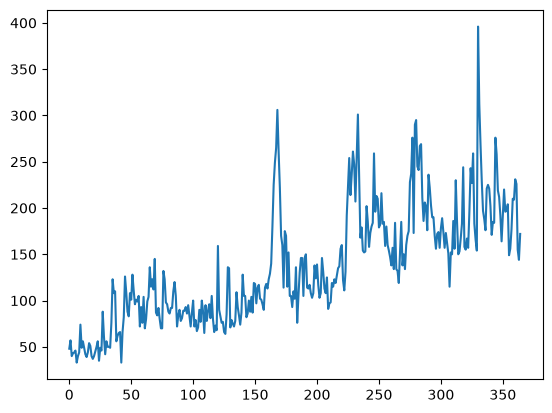

In [86]:
subs.plot()

<Axes: xlabel='lead'>

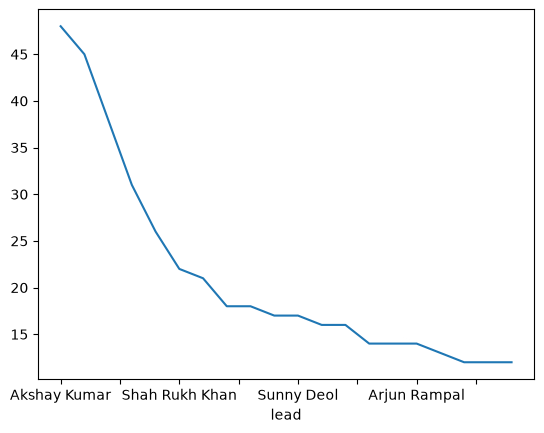

In [93]:
movies.value_counts().head(20).plot()

<Axes: >

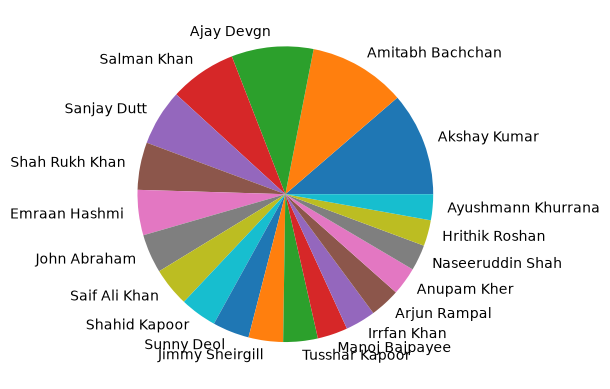

In [94]:
movies.value_counts().head(20).plot(kind='pie')

**Note:** `.plot()` is a thin wrapper around matplotlib — with no arguments it defaults to a line chart (good for a value that changes over time/order); `kind='pie'`, `kind='bar'`, etc. switch to other chart types.

## 16. 🔧 Some Important Series Methods

This section runs through several small-but-handy methods, one at a time: `astype`, `between`, `clip`, `drop_duplicates`, `isnull`/`dropna`/`fillna`, `isin`, `apply`, and `copy` (views vs. copies, revisited).

In [88]:
import numpy as np
import pandas as pd

In [91]:
subs = pd.read_csv('content/subs.csv').squeeze("columns")
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [ ]:
vk = pd.read_csv('/content/kohli_ipl.csv',index_col='match_no').squeeze("columns")
vk

In [ ]:
movies = pd.read_csv('/content/bollywood.csv',index_col='movie').squeeze("columns")
movies

In [ ]:
# astype
import sys
sys.getsizeof(vk)

In [ ]:
sys.getsizeof(vk.astype('int16'))

**Note:** shrinking to a smaller dtype (like `int16`) cuts memory the same way it did for NumPy arrays — but only works if every value actually fits in that smaller range.

In [ ]:
# between
vk[vk.between(51,99)].size

In [ ]:
vk.between(51, 99, inclusive='neither')   # exclude the boundary values themselves

In [ ]:
# clip
subs

In [ ]:
subs.clip(100,200)

**Note:** unlike `.between()` (which returns True/False), `.clip()` returns the actual **values**, pulling anything outside the range back to the nearest boundary.

In [ ]:
# drop_duplicates
temp = pd.Series([1,1,2,2,3,3,4,4])
temp

In [ ]:
temp.drop_duplicates(keep='last')

In [ ]:
temp.duplicated().sum()

In [ ]:
vk.duplicated().sum()

In [ ]:
movies.drop_duplicates()

**Note:** `.duplicated()` returns a boolean mask (`True` = "I've seen this value before"); `.drop_duplicates()` uses that same idea to remove the repeats outright. `keep='last'` keeps the last occurrence instead of the default first.

In [ ]:
temp = pd.Series([1,2,3,np.nan,5,6,np.nan,8,np.nan,10])
temp

In [ ]:
temp.size

In [ ]:
temp.count()

In [ ]:
# isnull
temp.isnull().sum()

**Note:** `np.nan` behaves in a Series exactly like it did in NumPy arrays — `isnull()`/`notnull()` are the reliable way to detect it (never compare with `==`).

In [ ]:
temp.isnull().mean() * 100   # % of the Series that's missing

In [ ]:
# dropna
temp.dropna()

In [ ]:
temp.dropna().size   # how many values are LEFT after dropping the missing ones (compare with temp.size above)

In [ ]:
# fillna
temp.fillna(temp.mean())

In [ ]:
temp.fillna(0)   # or fill with a fixed value instead of the mean

In [ ]:
# isin
vk[(vk == 49) | (vk == 99)]

In [ ]:
vk[vk.isin([49,99])]

In [ ]:
vk[~vk.isin([49, 99])].size   # the opposite: how many innings were NOT 49 or 99

In [ ]:
# apply
movies

In [ ]:
movies.apply(lambda x:x.split()[0].upper())

In [ ]:
subs

In [ ]:
subs.apply(lambda x:'good day' if x > subs.mean() else 'bad day')

In [ ]:
subs.mean()

**Note:** `.apply()` runs your function once per element and collects the results into a new Series — the pandas equivalent of a Python list comprehension, but the index comes along for free.

In [ ]:
# copy

**The gotcha, worked through step by step (as it behaved on older pandas):** selecting from a Series with `.head()` used to hand back a **view** that still shared memory with the original — editing what looked like an independent copy would silently edit the original too.

In [ ]:
vk

In [ ]:
new = vk.head()

In [ ]:
new

In [ ]:
new[1] = 1

**On older pandas, this is where `vk` would change too** — even though the code only touched `new`. On current pandas (Copy-on-Write, always on since 3.0), `vk` stays untouched here; `.copy()` below remains the explicit, version-proof way to guarantee independence.

In [ ]:
new = vk.head().copy()

In [ ]:
new[1] = 100

In [ ]:
new

In [ ]:
vk

## 17. ✅ Key Takeaways
- A Series is a NumPy array (`.values`) plus a label index (`.index`) — everything from the NumPy notebooks still applies.
- `squeeze=True` in `read_csv()` was removed in pandas 2.0+; use `.squeeze("columns")` instead.
- Plain `series[int]` treats the integer as a **label**, not a position — it can raise `KeyError` (getting) or silently create a stray new row (setting). Use `.iloc[]` for position, `.loc[]` for label, always.
- Slicing (`a:b:c`) is the one exception — it stays positional through plain `[]` even on a label-indexed Series.
- `in` checks the index by default, not the values — check `.values` explicitly if you want the values.
- Most methods return a **new** Series; `inplace=True` is the exception that overwrites the original.
- Copy-on-Write (mandatory since pandas 3.0) means slices no longer silently mutate their parent — but `.copy()` is still the explicit, version-proof habit to keep.